# Principal Component Analysis from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

**Principal Component Analysis (PCA)** is an unsupervised dimensionality reduction technique that projects data onto a lower-dimensional space while preserving as much variance as possible. It works by finding the **principal components**, which are the directions of maximum variance in the data.

The algorithm follows these steps:

1. Center the data by subtracting the mean
2. Compute the covariance matrix $\Sigma = \frac{1}{n} X^T X$
3. Find the eigenvectors and eigenvalues of $\Sigma$
4. Project data onto the top k eigenvectors (sorted by eigenvalue magnitude)

PCA is widely used for **visualization, noise reduction, feature engineering, and data compression**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_iris

from rice_ml.unsupervised_learning.pca import PCA
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Digits dataset**, which contains 1797 images of handwritten digits (0-9), each represented as an 8x8 grayscale image flattened into 64 features. This is a great dataset for PCA because the high dimensionality (64 features) makes visualization difficult.

In [3]:
data = load_digits()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Pixel value range: {X.min()} to {X.max()}")

Dataset shape: (1797, 64)
Number of classes: 10
Pixel value range: 0.0 to 16.0


## Visualizing Sample Digits

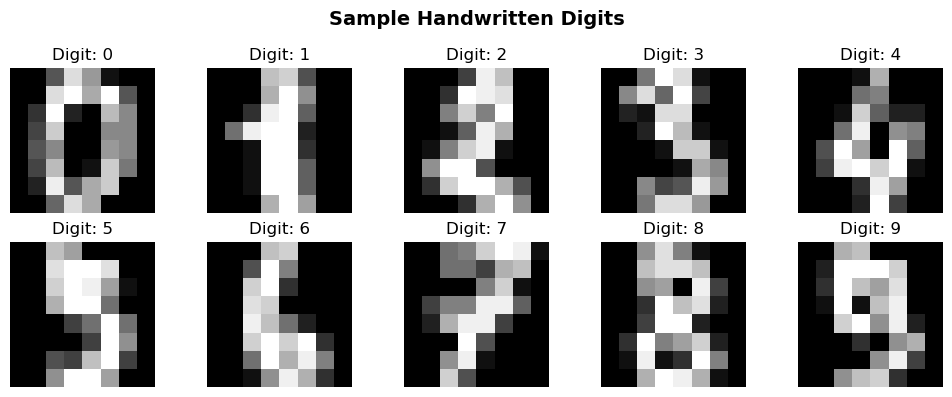

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flatten(), data.images[:10], data.target[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Digit: {label}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Reducing 64 Dimensions to 2 with PCA

In [5]:
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

pca = PCA(n_components=2).fit(X_scaled)
X_pca = pca.transform(X_scaled)

print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

Original shape: (1797, 64)
Reduced shape: (1797, 2)
Explained variance ratio: [0.12033916 0.09561054]
Total variance explained: 0.2159


## Visualizing the 2D Projection

Each color represents a different digit class. Even though we reduced from 64 dimensions to just 2, we can see meaningful separation between some digits.

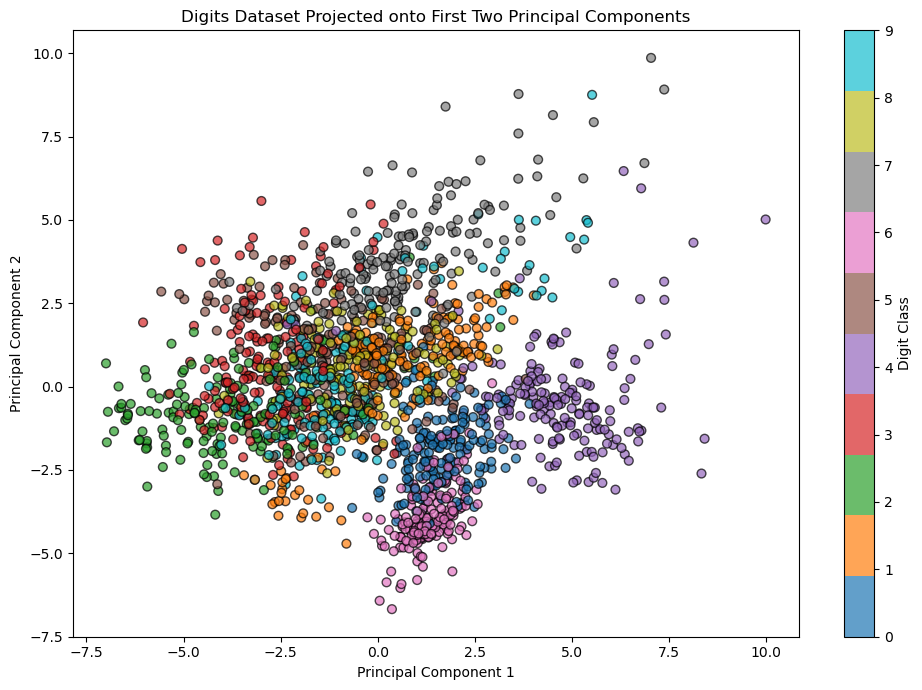

In [6]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10',
                      edgecolors='k', s=40, alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Digits Dataset Projected onto First Two Principal Components')
plt.colorbar(scatter, label='Digit Class')
plt.tight_layout()
plt.show()

## Explained Variance vs Number of Components

How many components do we need to capture most of the variance? The cumulative explained variance plot tells us.

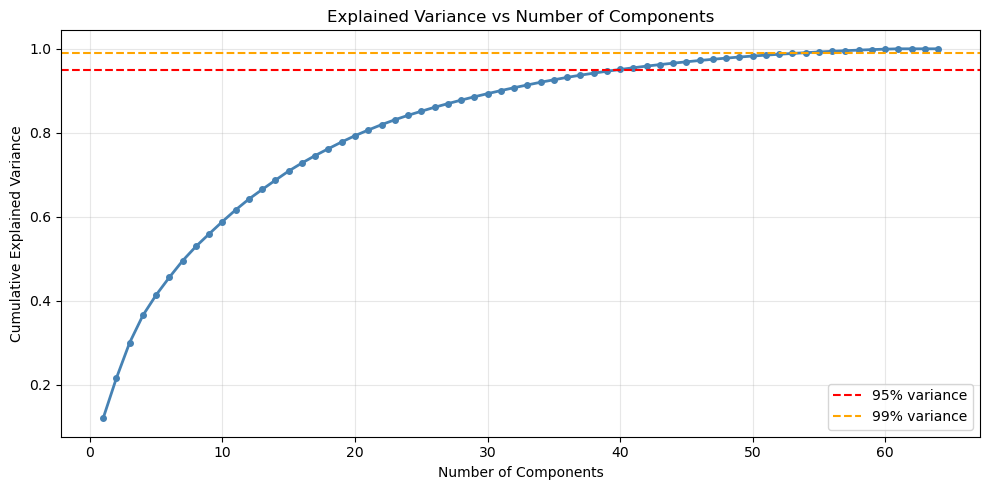

Components needed for 95% variance: 40
Components needed for 99% variance: 54


In [7]:
pca_full = PCA(n_components=64).fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 65), cumulative_variance, marker='o',
         linewidth=2, markersize=4, color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find component counts for variance thresholds
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")

## Reconstruction from Compressed Representation

PCA allows us to reconstruct approximate versions of the original data from the compressed representation. The more components we use, the better the reconstruction.

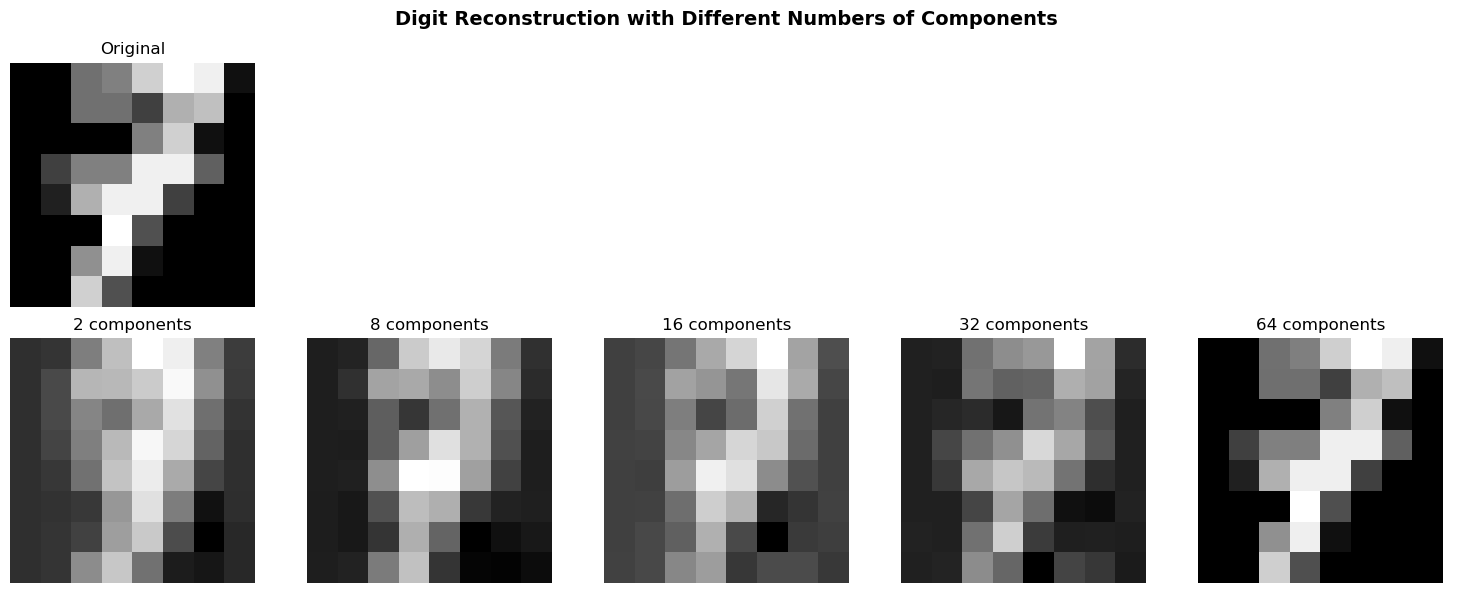

In [8]:
n_components_list = [2, 8, 16, 32, 64]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Original digit
sample_idx = 7
axes[0, 0].imshow(data.images[sample_idx], cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Reconstructions with different numbers of components
for i, n_c in enumerate(n_components_list):
    pca_n = PCA(n_components=n_c).fit(X_scaled)
    X_compressed = pca_n.transform(X_scaled[sample_idx:sample_idx+1])
    X_reconstructed = pca_n.inverse_transform(X_compressed)
    X_unscaled = scaler.inverse_transform(X_reconstructed)

    axes[1, i].imshow(X_unscaled.reshape(8, 8), cmap='gray')
    axes[1, i].set_title(f'{n_c} components')
    axes[1, i].axis('off')

axes[0, 1].axis('off')
axes[0, 2].axis('off')
axes[0, 3].axis('off')
axes[0, 4].axis('off')

plt.suptitle('Digit Reconstruction with Different Numbers of Components',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

- PCA successfully reduces the digits dataset from **64 dimensions to 2 dimensions** while still preserving meaningful structure for visualization
- The first two principal components capture only **21.59% of total variance**, which is expected for a complex high-dimensional dataset like handwritten digits
- Despite this dramatic compression, the **2D scatter plot** reveals clear cluster structure where some digits like 0, 4, and 6 form distinct groups while others overlap, showing that even drastic dimension reduction preserves substantial discriminative information
- The **cumulative variance plot** shows that **40 components capture 95% of variance** and **54 components capture 99%**, meaning we can compress the data by 38% while losing only 5% of information
- This is the core power of PCA, which is identifying redundant or correlated features and projecting onto orthogonal directions of maximum variance
- The **digit reconstruction visualization** beautifully illustrates the variance-quality tradeoff
- At 2 components, the reconstruction is barely recognizable as a digit, capturing only the most general shape information
- At 8 components, the digit becomes more distinguishable
- At 16-32 components, the reconstruction closely matches the original
- At 64 components, the reconstruction is mathematically identical to the original since we are using all dimensions
- This visualization makes the abstract concept of "explained variance" concrete by showing what information is lost at each compression level
- **Strengths** include linear and interpretable, computationally efficient, removes feature redundancy, useful for visualization and noise reduction
- **Weaknesses** include only captures linear relationships, sensitive to feature scaling (which is why we use StandardScaler), assumes high-variance directions are most important which may not always be true for classification
- For non-linear dimensionality reduction, more advanced methods like t-SNE or autoencoders are often used